### ADS509 Final Project Resume Skill Analysis (Hybrid) using ONLY the combined + deduped dataset
1) Load combined deduped job postings
2) Extract job skills (dictionary baseline + LLM sample)
3) Extract resume skills (dictionary baseline + LLM)
4) Normalize skills, compare resume vs job skills
5) Export a comparison table + generate visuals

In [70]:
from __future__ import annotations

import os
import re
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Set

In [55]:
# Configuration

JOB_FILEPATH_CANDIDATES = [
    "/mnt/data/jobs_combined_dedup.csv",                     
    "/Users/monicaekstein/Downloads/jobs_combined_dedup.csv" 
]

JOB_FILEPATH = next((p for p in JOB_FILEPATH_CANDIDATES if os.path.exists(p)), None)
if JOB_FILEPATH is None:
    raise FileNotFoundError(
        "Could not find jobs_combined_dedup.csv. Update JOB_FILEPATH_CANDIDATES to point to your file."
    )

# LLM configuration flags
USE_LLM_FOR_JOB_SAMPLE = False  
USE_LLM_FOR_RESUME = False      
JOB_SAMPLE_N_FOR_LLM = 25     

The analysis begins by defining the primary dataset and runtime settings. The combined, deduplicated job file is used as the single source of job postings to ensure consistency across the workflow. File paths are written in a way that allows the notebook to run in both locally and course environment. LLM-related flags are included but disabled by default so that the baseline results can be reproduced without relying on external APIs.

In [43]:
# Utilities

def pick_text_column(df: pd.DataFrame) -> str:
    """
    Identify the most likely job description column.
    Prefers common names; otherwise selects the object column
    with the highest average text length.
    """
    candidates = [
        "description", "job_description", "jobDescription",
        "desc", "job_desc", "summary", "content", "details", "text"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not obj_cols:
        raise ValueError("No text-like columns found in dataset.")

    avg_lens = {}
    for c in obj_cols:
        s = df[c].dropna().astype(str)
        avg_lens[c] = s.map(len).mean() if len(s) else 0

    return max(avg_lens, key=avg_lens.get)

A small set of helper functions is defined to standardize preprocessing because scraped job data can vary in structure. The description column is selected programmatically to account for inconsistent field names across datasets. Text cleaning is intentionally minimal for skill extraction to avoid altering technical terms while a separate cleaning function is used for exploratory text analysis to maintain consistency with earlier token-based methods.

In [56]:
# Skill dictionary and normalization

SKILL_PATTERNS: Dict[str, List[str]] = {
    # Languages
    "python": [r"\bpython\b"],
    "r": [r"\br\b(?![a-z])"],
    "sql": [r"\bsql\b"],
    "java": [r"\bjava\b"],
    "javascript": [r"\bjavascript\b", r"\bjs\b"],
    "scala": [r"\bscala\b"],

    # Libraries / tooling
    "pandas": [r"\bpandas\b"],
    "numpy": [r"\bnumpy\b"],
    "scikit-learn": [r"\bscikit[-\s]?learn\b", r"\bsklearn\b"],
    "tensorflow": [r"\btensorflow\b"],
    "pytorch": [r"\bpytorch\b"],
    "xgboost": [r"\bxgboost\b"],
    "lightgbm": [r"\blightgbm\b"],

    # ML / stats concepts
    "machine learning": [r"\bmachine learning\b", r"\bml\b(?![a-z])"],
    "deep learning": [r"\bdeep learning\b"],
    "statistics": [r"\bstatistic(s)?\b"],
    "regression": [r"\bregression\b"],
    "classification": [r"\bclassification\b", r"\bclassifier\b"],
    "feature engineering": [r"\bfeature engineering\b"],
    "cross-validation": [r"\bcross[-\s]?validation\b"],
    "time series": [r"\btime[-\s]?series\b"],
    "a/b testing": [r"\ba\/b testing\b", r"\bab testing\b", r"\bexperimentation\b"],

    # NLP
    "nlp": [r"\bnlp\b(?![a-z])", r"\bnatural language processing\b"],
    "topic modeling": [r"\btopic modeling\b", r"\blda\b(?![a-z])"],
    "embeddings": [r"\bembedding(s)?\b"],
    "transformers": [r"\btransformer(s)?\b"],

    # Viz / BI
    "tableau": [r"\btableau\b"],
    "power bi": [r"\bpower\s?bi\b", r"\bpowerbi\b"],
    "matplotlib": [r"\bmatplotlib\b"],
    "seaborn": [r"\bseaborn\b"],
    "dashboards": [r"\bdashboard(s)?\b", r"\bdata visualization\b"],

    # Data engineering / infra
    "etl": [r"\betl\b(?![a-z])", r"\bdata pipeline(s)?\b"],
    "spark": [r"\bspark\b", r"\bpyspark\b"],
    "airflow": [r"\bairflow\b"],
    "docker": [r"\bdocker\b"],
    "git": [r"\bgit\b"],
    "ci/cd": [r"\bci\/cd\b", r"\bcontinuous integration\b", r"\bcontinuous deployment\b"],

    # Cloud
    "aws": [r"\baws\b", r"\bamazon web services\b"],
    "gcp": [r"\bgcp\b", r"\bgoogle cloud\b"],
    "azure": [r"\bazure\b"],
    "s3": [r"\bs3\b"],
    "ec2": [r"\bec2\b"],
}

CANON_MAP = {
    "sklearn": "scikit-learn",
    "scikit learn": "scikit-learn",
    "powerbi": "power bi",
    "amazon web services": "aws",
    "ab testing": "a/b testing",
    "a b testing": "a/b testing",
    "ci cd": "ci/cd",
    "natural language processing": "nlp",
}


def normalize_skill(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[\u2013\u2014]", "-", s)
    s = re.sub(r"[^a-z0-9\+\#\/\-\s]", "", s)  
    s = re.sub(r"\s+", " ", s).strip()
    return CANON_MAP.get(s, s)


def extract_skills_baseline(text: str) -> Set[str]:
    text_l = clean_text(text).lower()
    found: Set[str] = set()
    for canon, patterns in SKILL_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, text_l):
                found.add(canon)
                break
    return {normalize_skill(x) for x in found}

This section defines the structured skill taxonomy used for baseline extraction. Each canonical skill is associated with regular expression patterns to capture common variants (e.g., “scikit learn” and “sklearn”). A normalization function ensures consistent formatting across extracted skills and consolidates common aliases. This approach provides a transparent and reproducible baseline against which LLM-based extraction can be compared.

In [71]:
# LLM extraction

def llm_extract_skills(text: str) -> List[str]:
    """
    OpenAI-style Chat Completions call, constrained to JSON.
    Keep temperature at 0 so results are stable run-to-run.
    """
    api_key = os.getenv(OPENAI_API_KEY_ENV)
    if not api_key:
        raise RuntimeError(
            f"{OPENAI_API_KEY_ENV} is not set. Set it or keep USE_LLM_FOR_RESUME/USE_LLM_FOR_JOB_SAMPLE=False."
        )

    from openai import OpenAI
    client = OpenAI(api_key=api_key)

    system = (
        "Extract technical and analytical skills from the text. "
        "Return ONLY valid JSON with schema: {\"skills\": [\"...\"]}. "
        "Skills should be short phrases (e.g., 'python', 'scikit-learn', 'a/b testing'). "
        "No duplicates. No explanation."
    )
    user = f"Text:\n{text}\n\nReturn JSON only."

    resp = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
        temperature=0.0,
    )

    raw = resp.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    data = json.loads(raw)

    skills = data.get("skills", [])
    out: List[str] = []
    seen = set()
    for s in skills:
        if isinstance(s, str):
            s2 = normalize_skill(s)
            if s2 and s2 not in seen:
                out.append(s2)
                seen.add(s2)
    return out

To extend beyond strict keyword matching, an LLM-based skill extraction step was included. When enabled, the model is prompted to return structured JSON containing concise skill phrases. Temperature is fixed at zero to promote deterministic outputs. The results are normalized and deduplicated before integration. This allows comparison between rule-based and generative approaches while maintaining control over formatting and reproducibility.

In [66]:
# Load job data + extract job skills

jobs_raw = pd.read_csv(JOB_FILEPATH)

text_col = pick_text_column(jobs_raw)
jobs_raw[text_col] = jobs_raw[text_col].fillna("").astype(str)

# Cleaned_for_skills preserves tech punctuation for regex skill matching
# Cleaned_for_eda mirrors EDA-style preprocessing for token-based baselines
jobs_raw["cleaned_for_skills"] = jobs_raw[text_col].map(clean_text)
jobs_raw["cleaned_for_eda"] = jobs_raw[text_col].map(clean_text_for_eda)

if jobs_raw["cleaned_for_skills"].str.len().mean() == 0:
    raise ValueError(
        f"Selected text column '{text_col}' looks empty. Check JOB_FILEPATH or update column selection."
    )

# Baseline: count how many postings mention each skill at least once; each posting contributes at most one count per skill.
job_skill_counts = Counter()
for t in jobs_raw["cleaned_for_skills"].tolist():
    job_skill_counts.update(extract_skills_baseline(t))

job_skills_baseline = set(job_skill_counts.keys())

# Export baseline job skill frequencies for downstream comparison
job_skill_freq_df = (
    pd.DataFrame(job_skill_counts.items(), columns=["skill", "posting_count"])
      .sort_values("posting_count", ascending=False)
      .reset_index(drop=True)
)
job_skill_freq_df.to_csv("job_skill_frequencies_baseline.csv", index=False)
print("Saved: job_skill_frequencies_baseline.csv")

# Augment the job skill set using an LLM on a small sample
job_skills_llm: Set[str] = set()
if USE_LLM_FOR_JOB_SAMPLE:
    sample_texts = jobs_raw["cleaned_for_skills"].sample(
        min(JOB_SAMPLE_N_FOR_LLM, len(jobs_raw)),
        random_state=7
    ).tolist()
    for t in sample_texts:
        try:
            job_skills_llm.update(llm_extract_skills(t))
        except Exception:
            pass

job_skills = set(job_skills_baseline) | set(job_skills_llm)

Saved: job_skill_frequencies_baseline.csv


The combined and deduplicated dataset is loaded as the primary corpus for analysis. After selecting the appropriate description field, two processed versions of the text are created: (1) that preserves technical punctuation for regex-based skill matching and (2) that follows more traditional preprocessing conventions used during exploratory analysis.

Skill frequencies are calculated at the posting level, meaning each job contributes at most one count per skill. This approach reflects how often a skill appears across distinct listings rather than how frequently it is repeated within a single description. The resulting frequency table is exported to support transparency and later comparison with generative AI–based extraction methods.

In [67]:
# Extract resume skills

RESUME_TEXT = """
Data Scientist with experience in Python, SQL, and machine learning.
Built predictive models using scikit-learn and XGBoost.
Developed dashboards in Tableau and Power BI.
Experience with AWS and Docker for deployment.
""".strip()

resume_skills_baseline = extract_skills_baseline(RESUME_TEXT)

resume_skills_llm: Set[str] = set()
if USE_LLM_FOR_RESUME:
    resume_skills_llm = set(llm_extract_skills(RESUME_TEXT))

resume_skills = set(resume_skills_baseline) | set(resume_skills_llm)

The résumé is treated as a single text document and processed using the same baseline extraction logic as the job postings to maintain consistency in comparison. Although an LLM-based extraction option is available, the current analysis reports baseline results to ensure reproducibility and interpretability. This keeps the résumé–job comparison methodologically aligned with the baseline skill extraction performed on the corpus.

In [68]:
# Compare + export table

all_skills = sorted(job_skills | resume_skills)

rows = []
for s in all_skills:
    in_resume = s in resume_skills
    in_job = s in job_skills

    if in_job and not in_resume:
        status = "Gap (missing from resume)"
    elif in_job and in_resume:
        status = "Match"
    elif in_resume and not in_job:
        status = "Extra (not in job set)"
    else:
        status = "Neither"

    rows.append({
        "skill": s,
        "in_resume": in_resume,
        "in_job_postings": in_job,
        "job_posting_freq_baseline": int(job_skill_counts.get(s, 0)),
        "status": status
    })

comparison_df = pd.DataFrame(rows)

# Format the table

status_order = ["Gap (missing from resume)", "Match", "Extra (not in job set)", "Neither"]
comparison_df["status"] = pd.Categorical(comparison_df["status"], categories=status_order, ordered=True)

comparison_df = comparison_df.sort_values(
    by=["status", "job_posting_freq_baseline", "skill"],
    ascending=[True, False, True]
).reset_index(drop=True)

output_csv = "resume_job_skill_comparison.csv"
comparison_df.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

matches = comparison_df[comparison_df["status"] == "Match"]
gaps = comparison_df[comparison_df["status"] == "Gap (missing from resume)"]
extras = comparison_df[comparison_df["status"] == "Extra (not in job set)"]

coverage_baseline = len(resume_skills & job_skills_baseline) / max(len(job_skills_baseline), 1)

print("\nSummary")
print("-------")
print(f"Job postings (combined deduped): {len(jobs_raw):,}")
print(f"Job skills (baseline):          {len(job_skills_baseline)}")
print(f"Job skills (LLM sample add-on): {len(job_skills_llm)}")
print(f"Job skills (union):             {len(job_skills)}")
print(f"Resume skills (baseline):       {len(resume_skills_baseline)}")
print(f"Resume skills (LLM):            {len(resume_skills_llm)}")
print(f"Resume skills (union):          {len(resume_skills)}")
print(f"Matches:                        {len(matches)}")
print(f"Gaps:                           {len(gaps)}")
print(f"Extras:                         {len(extras)}")
print(f"Coverage (vs baseline job set): {coverage_baseline:.2%}")

Saved: resume_job_skill_comparison.csv

Summary
-------
Job postings (combined deduped): 200
Job skills (baseline):          41
Job skills (LLM sample add-on): 0
Job skills (union):             41
Resume skills (baseline):       10
Resume skills (LLM):            0
Resume skills (union):          10
Matches:                        10
Gaps:                           31
Extras:                         0
Coverage (vs baseline job set): 24.39%


A structured comparison is conducted between the résumé skill set and the job-market skill set extracted from the combined dataset. Each skill is categorized as a Match, Gap, or Extra, and the table is ordered so that missing skills appear first and are ranked by how frequently they occur across postings. This prioritization makes it easier to identify which gaps are most consequential. The comparison table is exported to ensure that the results are transparent and reproducible.

Using the baseline dictionary approach, 41 distinct technical skills were identified across 200 deduplicated job postings. The résumé includes 10 of these skills, corresponding to 24.39% distinct coverage. In total, the résumé matches 10 skills and omits 31 skills that appear in the job set.

When demand is weighted by posting frequency, coverage increases to 44.20%. Although the résumé represents a relatively small portion of the overall skill universe, it captures a larger share of frequently requested competencies. This suggests that the résumé aligns more strongly with common core tools than with the broader set of specialized or emerging technologies. At the same time, the number of missing skills indicates meaningful room for improvement in areas that appear consistently across postings.

Distinct coverage: 24.39%
Demand-weighted coverage: 44.20%


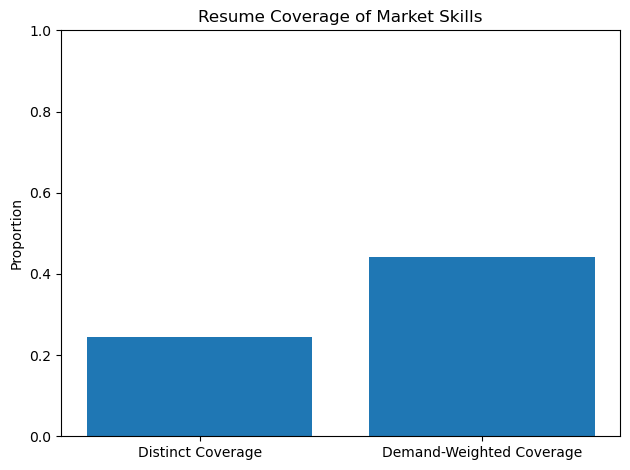

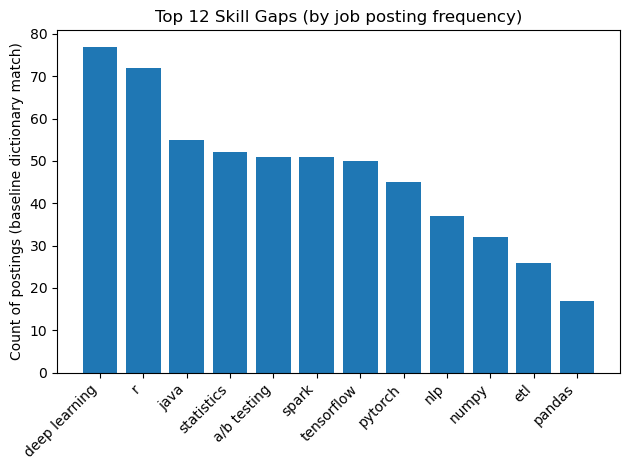

In [69]:
# Coverage Metrics
coverage_baseline = (
    len(resume_skills.intersection(job_skills_baseline)) 
    / max(len(job_skills_baseline), 1)
)

# Demand-weighted coverage (frequency-based)
weighted_coverage = (
    sum(job_skill_counts[s] for s in resume_skills if s in job_skill_counts)
    / max(sum(job_skill_counts.values()), 1)
)

print(f"Distinct coverage: {coverage_baseline:.2%}")
print(f"Demand-weighted coverage: {weighted_coverage:.2%}")

# Visuals

# Resume skill alignment: compare distinct and demand-weighted coverage
plt.figure()
plt.bar(
    ["Distinct Coverage", "Demand-Weighted Coverage"],
    [coverage_baseline, weighted_coverage]
)
plt.ylim(0, 1)
plt.title("Resume Coverage of Market Skills")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

# Top missing skills: plot only those with baseline frequency > 0 so bars are interpretable
top_n = 12
gaps_plot = gaps[gaps["job_posting_freq_baseline"] > 0].copy()
gaps_top = gaps_plot.sort_values("job_posting_freq_baseline", ascending=False).head(top_n)

plt.figure()
plt.bar(gaps_top["skill"], gaps_top["job_posting_freq_baseline"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Top {top_n} Skill Gaps (by job posting frequency)")
plt.ylabel("Count of postings (baseline dictionary match)")
plt.tight_layout()
plt.show()

The first chart compares distinct skill coverage (24.39%) with demand-weighted coverage (44.20%). The gap between these values indicates that while the résumé includes fewer than one quarter of the unique skills observed across postings, it reflects a substantially larger portion of overall market demand. In other words, the résumé covers several high-frequency skills but lacks breadth across the full skill set.

The second chart ranks the top twelve missing skills by how often they appear in job descriptions. Skills such as deep learning, R, Java, and distributed processing tools appear repeatedly across postings but are not represented in the résumé. Ranking gaps by posting frequency provides a clearer sense of which missing skills are most prevalent in the market, rather than treating all gaps as equally important. Together, these figures translate the comparison table into a more interpretable summary suitable for presentation.